# Verify `IM1923_SF5-Sucrose_20251106.nwb`

Quick visual sanity check of the sham-feeding conversion: session/subject metadata, raw photometry per region (gACh4h 470 / rDA3m 565 / 405 gACh4h reference), licking, engagement, DLC distance, and peri-event photometry aligned to lick onset and approach.

Run with the `jdb_to_nwb` conda env (has `pynwb` + `ndx_fiber_photometry`).

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from pynwb import NWBHDF5IO

NWB_PATH = "IM1923_SF5-Sucrose_20251106.nwb"
WL_COLORS = {470: "#2CA02C", 565: "#D62728", 405: "#8FBF8F"}  # green ACh, red DA, desat. 405 reference

io = NWBHDF5IO(NWB_PATH, mode="r")
nwb = io.read()


def tvec(ts):
    """Time vector (seconds) for a TimeSeries, whether it uses rate or explicit timestamps."""
    if ts.timestamps is not None:
        return np.asarray(ts.timestamps[:])
    n = ts.data.shape[0]
    t0 = ts.starting_time if ts.starting_time is not None else 0.0
    return t0 + np.arange(n) / ts.rate


# Raw + filtered + hampel photometry and digital sync all live in nwb.acquisition.
behavior = nwb.processing["behavior"]
dlc = nwb.processing["dlc"]

# Each recording side is named hemisphere+region (e.g. "left_mNacSh") so the same region in
# both hemispheres stays unique. Read the side labels straight from the metadata table.
SIDES = list(nwb.processing["session_metadata"]["session_side_metadata"].to_dataframe()["side_label"])
print("sides:", SIDES)
print(nwb)

sides: ['left_mNacSh', 'right_NacCore']
root pynwb.file.NWBFile at 0x4828511312
Fields:
  acquisition: {
    digital_sync_left_mNacSh <class 'pynwb.base.TimeSeries'>,
    digital_sync_right_NacCore <class 'pynwb.base.TimeSeries'>,
    filt_405_left_mNacSh <class 'abc.FiberPhotometryResponseSeries'>,
    filt_405_right_NacCore <class 'abc.FiberPhotometryResponseSeries'>,
    filt_470_left_mNacSh <class 'abc.FiberPhotometryResponseSeries'>,
    filt_470_right_NacCore <class 'abc.FiberPhotometryResponseSeries'>,
    filt_565_left_mNacSh <class 'abc.FiberPhotometryResponseSeries'>,
    filt_565_right_NacCore <class 'abc.FiberPhotometryResponseSeries'>,
    hampel_405_left_mNacSh <class 'abc.FiberPhotometryResponseSeries'>,
    hampel_405_right_NacCore <class 'abc.FiberPhotometryResponseSeries'>,
    hampel_470_left_mNacSh <class 'abc.FiberPhotometryResponseSeries'>,
    hampel_470_right_NacCore <class 'abc.FiberPhotometryResponseSeries'>,
    hampel_565_left_mNacSh <class 'abc.FiberPhotome

## 1. Session / subject metadata + per-side summary table

In [24]:
s = nwb.subject
print("session_id:        ", nwb.session_id)
print("session_start_time:", nwb.session_start_time)
print("experimenter:      ", nwb.experimenter)
print("institution / lab: ", nwb.institution, "/", nwb.lab)
print("subject:           ", s.subject_id, s.species, s.sex, s.strain, "DOB", s.date_of_birth)
print("\nnotes:\n", nwb.notes)

nwb.processing["session_metadata"]["session_side_metadata"].to_dataframe().T

session_id:         IM1923_SF5-Sucrose_20251106
session_start_time: 2025-11-06 09:31:35.090000-08:00
experimenter:       ('Slomp, Margo',)
institution / lab:  University of California, San Francisco / Berke Lab
subject:            IM1923 Rattus norvegicus M WT (PV-) DOB 2025-04-29 00:00:00-07:00

notes:
 Sham-feeding SF5-Sucrose trial. Left hemisphere (COM3) recorded from mNacSh (target mNacSh); Right hemisphere (COM4) recorded from NacCore (target NacCore). Grams consumed: 81.82 g; grams in pan: 80.84 g. pyPhotometry mode '3EX_2EM_pulsed', sampling rate 86 Hz, LED current [10, 47] mA, volts/division [0.00010122, 0.00010122].


id,0,1
side_label,left_mNacSh,right_NacCore
side,Left,Right
com_port,COM3,COM4
region,mNacSh,NacCore
hemisphere,left,right
hit,mNacSh,NacCore
target,mNacSh,NacCore
full_side_name,COM3_Left_mNacSh,COM4_Right_NacCore
indicator_470nm,gACh4h,gACh4h
indicator_565nm,rDA3m,rDA3m


## 2. Raw photometry — full session, both regions

Downsampled purely for plotting speed. Expect slow photobleaching decay; the 405 nm gACh4h reference should track common motion/bleaching but not signal transients.

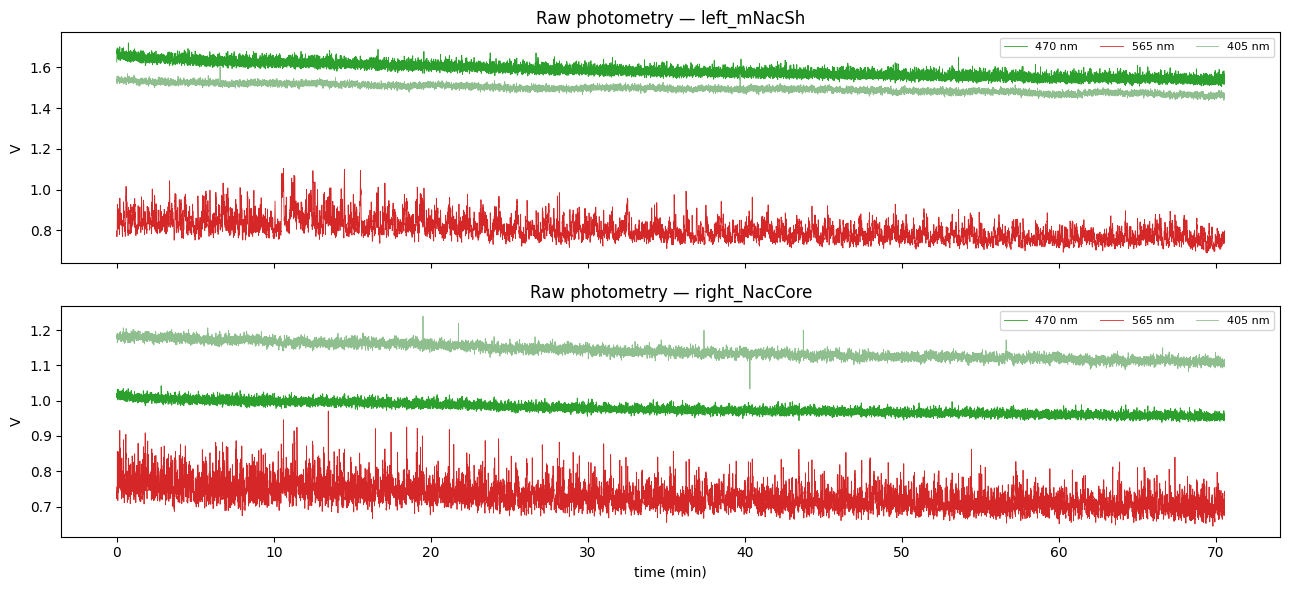

In [25]:
ds = 20  # plot every 20th sample (~4.3 Hz)
fig, axes = plt.subplots(len(SIDES), 1, figsize=(13, 6), sharex=True)
for ax, side in zip(axes, SIDES):
    for wl in (470, 565, 405):
        ts = nwb.acquisition[f"raw_{wl}_{side}"]
        t = tvec(ts)[::ds]
        ax.plot(t / 60, ts.data[::ds], color=WL_COLORS[wl], lw=0.6, label=f"{wl} nm")
    ax.set_title(f"Raw photometry — {side}")
    ax.set_ylabel("V")
    ax.legend(loc="upper right", ncol=3, fontsize=8)
axes[-1].set_xlabel("time (min)")
fig.tight_layout()

## 3. Licking overview — cumulative licks, lick rate, burst structure

left_mNacSh: 74 bursts, mean 301 licks/burst, mean burst dur 18.8 s
right_NacCore: 74 bursts, mean 301 licks/burst, mean burst dur 18.8 s


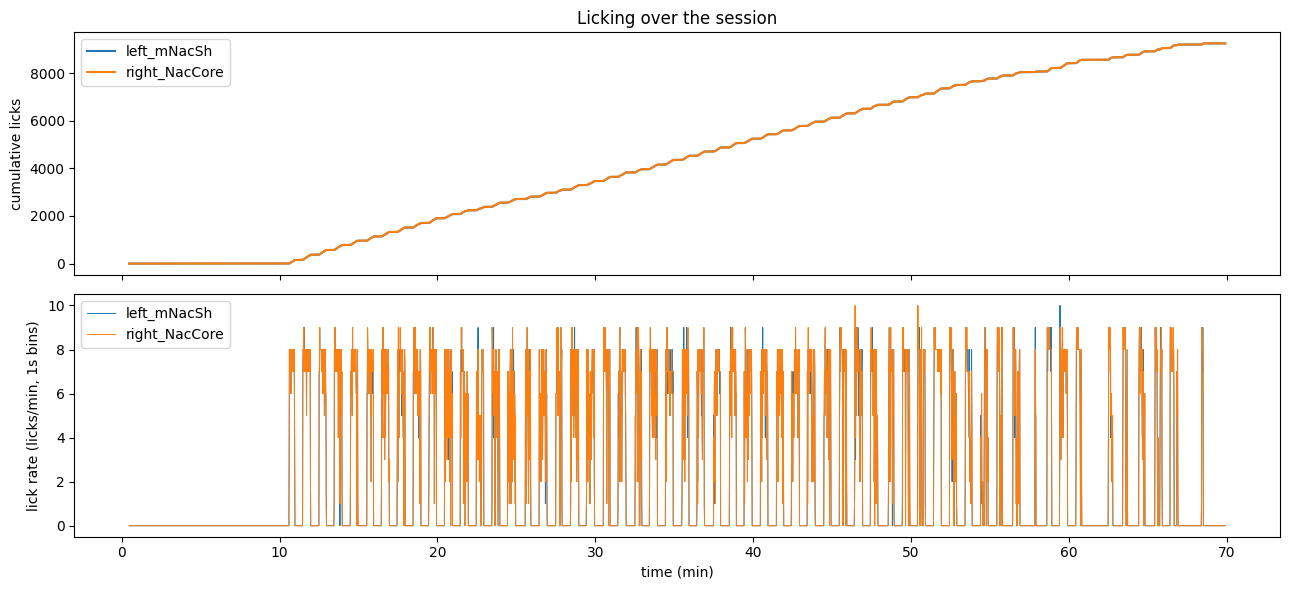

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
for side in SIDES:
    cl = behavior[f"cumulative_licks_{side}"]
    axes[0].plot(tvec(cl) / 60, cl.data[:], label=side)
    lr = behavior[f"lickrate_1s_{side}"]
    axes[1].plot(tvec(lr) / 60, lr.data[:], lw=0.7, label=side)
axes[0].set_ylabel("cumulative licks"); axes[0].legend()
axes[1].set_ylabel("lick rate (licks/min, 1s bins)"); axes[1].set_xlabel("time (min)"); axes[1].legend()
axes[0].set_title("Licking over the session")
fig.tight_layout()

for side in SIDES:
    bt = behavior[f"burst_table_{side}"].to_dataframe()
    print(f"{side}: {len(bt)} bursts, mean {bt['avg_licks_per_burst'].mean():.0f} licks/burst, "
          f"mean burst dur {bt['lick_burst_duration_ms'].mean()/1000:.1f} s")

## 4. Zoom: photometry + licks + engagement + DLC distance

A 60 s window in the middle of the session. Check that licks, engagement and short head-to-spout distance line up, and that photometry transients occur during bouts.

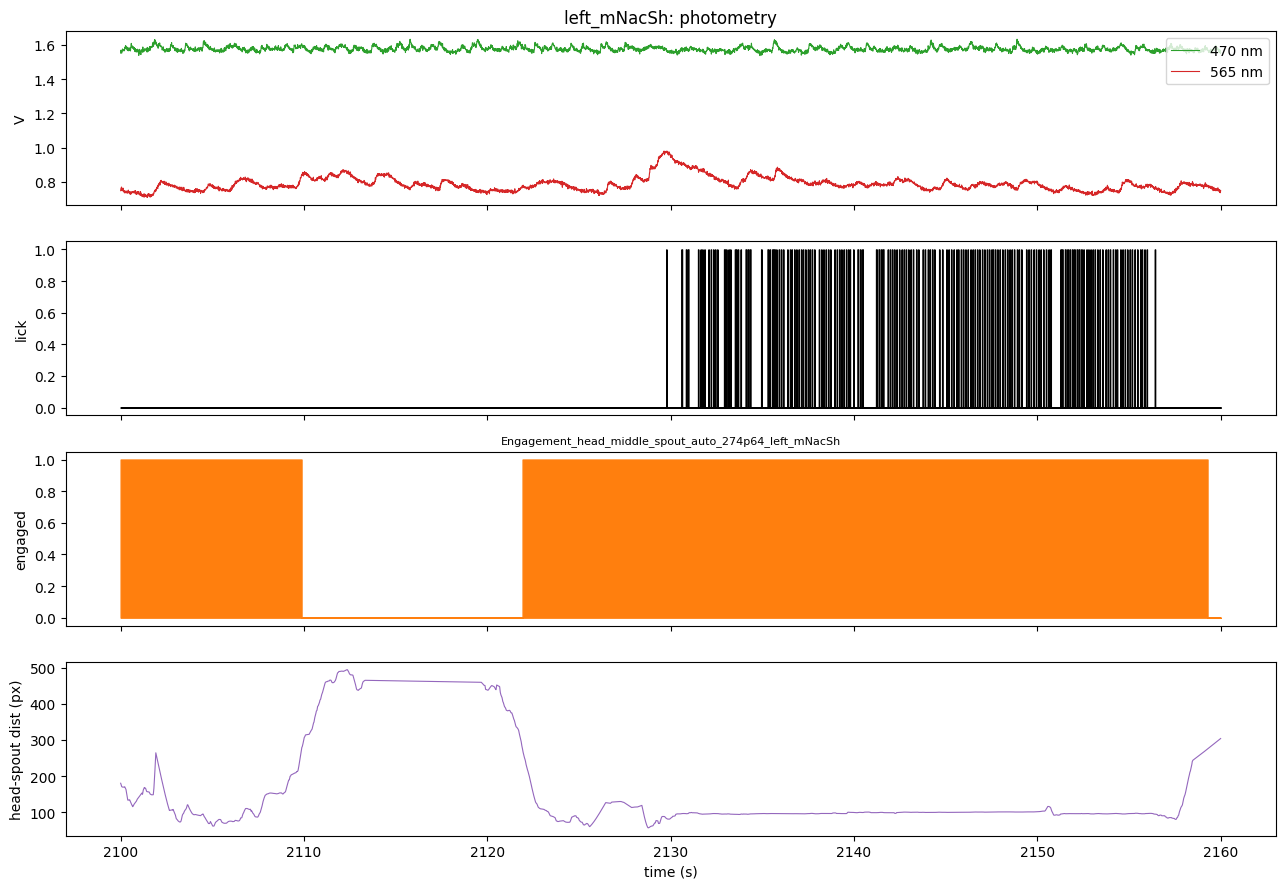

In [27]:
side = SIDES[0]
t_start, t_dur = 35 * 60, 60  # seconds

def window(ts, t0, dur):
    t = tvec(ts)
    m = (t >= t0) & (t <= t0 + dur)
    return t[m], np.asarray(ts.data[:])[m]

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)

for wl in (470, 565):
    t, y = window(nwb.acquisition[f"raw_{wl}_{side}"], t_start, t_dur)
    axes[0].plot(t, y, color=WL_COLORS[wl], lw=0.8, label=f"{wl} nm")
axes[0].set_ylabel("V"); axes[0].legend(loc="upper right"); axes[0].set_title(f"{side}: photometry")

t, y = window(behavior[f"lick_binary_{side}"], t_start, t_dur)
axes[1].fill_between(t, 0, np.nan_to_num(y), step="mid", color="k"); axes[1].set_ylabel("lick")

eng_key = [k for k in behavior.data_interfaces if k.startswith("Engagement") and k.endswith(side) and "auto" in k][0]
t, y = window(behavior[eng_key], t_start, t_dur)
axes[2].fill_between(t, 0, y, step="mid", color="tab:orange"); axes[2].set_ylabel("engaged")
axes[2].set_title(eng_key, fontsize=8)

t, y = window(dlc[f"DLC_Distance_head_middle_spout_{side}"], t_start, t_dur)
axes[3].plot(t, y, color="tab:purple", lw=0.8)
axes[3].set_ylabel("head-spout dist (px)"); axes[3].set_xlabel("time (s)")
fig.tight_layout()

## 5. Peri-event photometry — aligned to lick-bout onset

Average raw signal around the first lick of each burst (bout onset). This is the key biological sanity check: dopamine (rDA3m, 565) and ACh (gACh4h, 470) should show structured responses around consummatory onset, while the 405 nm gACh4h reference should stay comparatively flat.

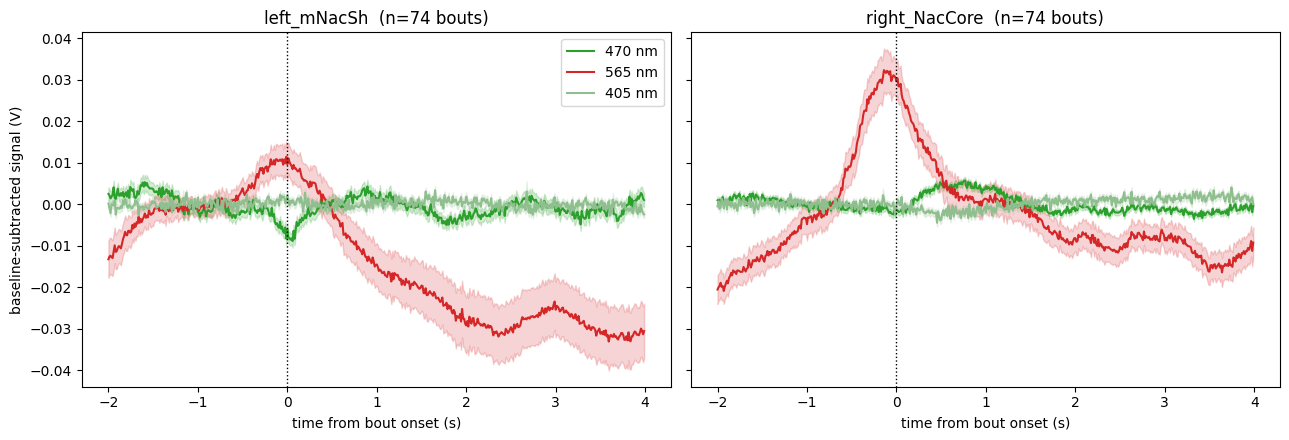

In [28]:
def bout_onsets(side, min_gap_s=2.0):
    """Lick-event times separated by >= min_gap_s, i.e. bout starts."""
    le = behavior[f"lick_events_{side}"]
    t = np.asarray(le.timestamps[:])
    if t.size == 0:
        return t
    keep = np.concatenate([[True], np.diff(t) >= min_gap_s])
    return t[keep]

def peri_event(ts, event_times, pre=2.0, post=4.0):
    t = tvec(ts); y = np.asarray(ts.data[:])
    fs = ts.rate if ts.rate is not None else 1.0 / np.median(np.diff(t))
    npre, npost = int(pre * fs), int(post * fs)
    lag = (np.arange(-npre, npost)) / fs
    snips = []
    for et in event_times:
        i = int(round((et - t[0]) * fs))
        if i - npre >= 0 and i + npost < len(y):
            seg = y[i - npre:i + npost].astype(float)
            snips.append(seg - np.nanmean(seg[:npre]))  # baseline-subtract pre-window
    return lag, np.array(snips)

fig, axes = plt.subplots(1, len(SIDES), figsize=(13, 4.5), sharey=True)
for ax, side in zip(axes, SIDES):
    onsets = bout_onsets(side)
    for wl in (470, 565, 405):
        lag, snips = peri_event(nwb.acquisition[f"raw_{wl}_{side}"], onsets)
        if snips.size == 0:
            continue
        mean, sem = snips.mean(0), snips.std(0) / np.sqrt(len(snips))
        ax.plot(lag, mean, color=WL_COLORS[wl], label=f"{wl} nm")
        ax.fill_between(lag, mean - sem, mean + sem, color=WL_COLORS[wl], alpha=0.2)
    ax.axvline(0, color="k", ls=":", lw=1)
    ax.set_title(f"{side}  (n={len(onsets)} bouts)")
    ax.set_xlabel("time from bout onset (s)")
axes[0].set_ylabel("baseline-subtracted signal (V)"); axes[0].legend()
fig.tight_layout()

## 6. Peri-event photometry — aligned to spout approach

Uses the `approach_events` from the distance-state detection.

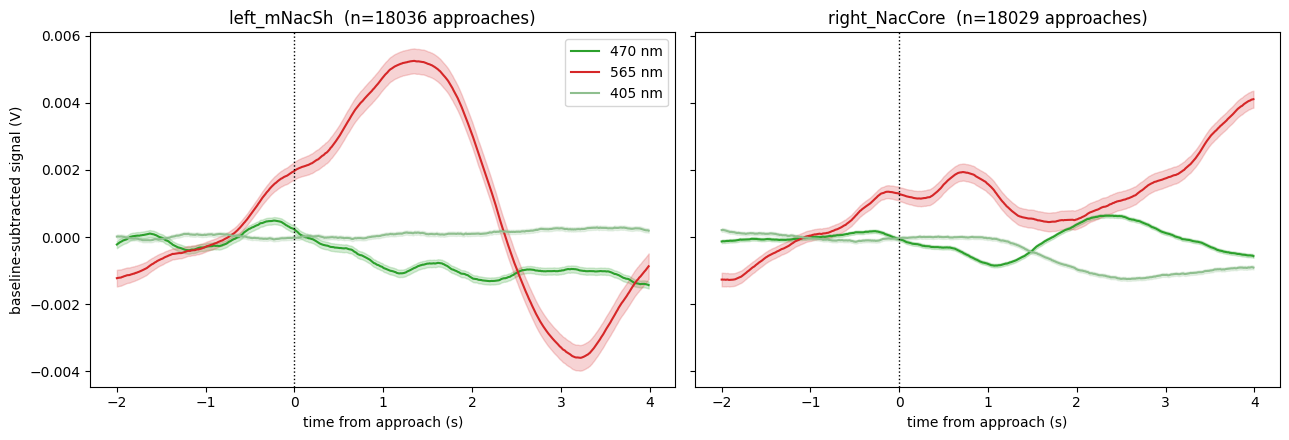

In [29]:
fig, axes = plt.subplots(1, len(SIDES), figsize=(13, 4.5), sharey=True)
for ax, side in zip(axes, SIDES):
    appr = behavior[f"approach_events_{side}"]
    at = tvec(appr); av = np.asarray(appr.data[:])
    approach_times = at[av > 0]
    for wl in (470, 565, 405):
        lag, snips = peri_event(nwb.acquisition[f"raw_{wl}_{side}"], approach_times)
        if snips.size == 0:
            continue
        mean, sem = snips.mean(0), snips.std(0) / np.sqrt(len(snips))
        ax.plot(lag, mean, color=WL_COLORS[wl], label=f"{wl} nm")
        ax.fill_between(lag, mean - sem, mean + sem, color=WL_COLORS[wl], alpha=0.2)
    ax.axvline(0, color="k", ls=":", lw=1)
    ax.set_title(f"{side}  (n={len(approach_times)} approaches)")
    ax.set_xlabel("time from approach (s)")
axes[0].set_ylabel("baseline-subtracted signal (V)"); axes[0].legend()
fig.tight_layout()

## 7. Inventory of everything in the file

In [30]:
print("ACQUISITION (raw + filtered + hampel photometry, digital sync):")
for k, v in nwb.acquisition.items():
    print(f"  {k:34s} {getattr(v.data, 'shape', '?')}")
for mod in ("behavior", "dlc", "session_metadata"):
    print(f"\n{mod.upper()}:")
    for k in nwb.processing[mod].data_interfaces:
        print(f"  {k}")

ACQUISITION (raw + filtered + hampel photometry, digital sync):
  digital_sync_left_mNacSh           (364042,)
  digital_sync_right_NacCore         (364047,)
  filt_405_left_mNacSh               (364042,)
  filt_405_right_NacCore             (364047,)
  filt_470_left_mNacSh               (364042,)
  filt_470_right_NacCore             (364047,)
  filt_565_left_mNacSh               (364042,)
  filt_565_right_NacCore             (364047,)
  hampel_405_left_mNacSh             (364042,)
  hampel_405_right_NacCore           (364047,)
  hampel_470_left_mNacSh             (364042,)
  hampel_470_right_NacCore           (364047,)
  hampel_565_left_mNacSh             (364042,)
  hampel_565_right_NacCore           (364047,)
  raw_405_left_mNacSh                (364042,)
  raw_405_right_NacCore              (364047,)
  raw_470_left_mNacSh                (364042,)
  raw_470_right_NacCore              (364047,)
  raw_565_left_mNacSh                (364042,)
  raw_565_right_NacCore              (36404

## 8. Programmatic checks — schema, inspector, round-trip vs source pickle

Beyond the visual plots: validate against the NWB schema, run nwbinspector for best-practice issues, and confirm a sample of arrays (raw/filtered/hampel photometry, lick binary, cumulative licks, cleaned head distance) match the original `*_lickprocessed.pkl` **exactly** — the real test that the conversion is faithful.

In [31]:
# Programmatic verification: NWB schema, best-practice inspection, and round-trip vs the source pickle.
from pynwb import validate

errs = validate(paths=[NWB_PATH])
print(f"Schema validation: {len(errs)} error(s)")
for e in errs[:10]:
    print("  ", e)

try:
    from nwbinspector import inspect_nwbfile
    flagged = [m for m in inspect_nwbfile(nwbfile_path=NWB_PATH)
               if m.importance.name != "BEST_PRACTICE_SUGGESTION"]
    print(f"\nnwbinspector: {len(flagged)} non-suggestion message(s)")
    for m in flagged[:12]:
        print(f"  [{m.importance.name}] {m.check_function_name}: {m.message[:85]}")
except Exception as ex:
    print("\nnwbinspector unavailable:", ex)

# Round-trip: confirm a sample of arrays match the source pickle exactly (the real faithfulness check).
import glob, pickle
pkls = sorted(glob.glob(f"{nwb.subject.subject_id}_*_lickprocessed.pkl"))
if not pkls:
    print("\nSource pickle not found next to the notebook — skipping round-trip check.")
else:
    src = pickle.load(open(pkls[0], "rb"))

    def _label(e):  # rebuild the side label the converter used, from Full_side_name
        p = str(e["Full_side_name"]).split("_")
        reg = next((r for r in ("NacCore", "mNacSh") if "_".join(p[2:]).endswith(r)), "_".join(p[2:]))
        return f"{p[1].lower()}_{reg}"
    src_by_label = {_label(e): e for e in src}

    checks = []
    def chk(name, arr, store):
        a, b = np.asarray(store[name].data[:]), np.asarray(arr, dtype="float64")
        checks.append((name, a.shape == b.shape and np.allclose(a, b, equal_nan=True)))

    for side in SIDES:
        e = src_by_label[side]
        bv = e["LickBurst_Vars_BurstDefinitionILI_basedThresh2000"]
        chk(f"raw_470_{side}", e["analog_1"], nwb.acquisition)
        chk(f"raw_565_{side}", e["analog_2"], nwb.acquisition)
        chk(f"raw_405_{side}", e["analog_3"], nwb.acquisition)
        chk(f"filt_470_{side}", e["analog_1_filt"], nwb.acquisition)
        chk(f"hampel_405_{side}", e["analog3_hampel"], nwb.acquisition)
        chk(f"lick_binary_{side}", e["LickBinary_2.3"], behavior)
        chk(f"cumulative_licks_{side}", bv["CumLicks"], behavior)
        chk(f"cleaned_head_distance_{side}", e["Cleaned_Head_Distance"], behavior)

    n_fail = sum(not ok for _, ok in checks)
    print(f"\nRound-trip vs {pkls[0]}: {len(checks) - n_fail}/{len(checks)} arrays match exactly")
    for name, ok in checks:
        if not ok:
            print("  MISMATCH:", name)

Schema validation: 0 error(s)

nwbinspector unavailable: No module named 'nwbinspector'

Round-trip vs IM1923_Trial-SF5-Sucrose_11-06-2025_lickprocessed.pkl: 16/16 arrays match exactly


## 9. Devices, coordinates & cross-side clock drift

Confirm the fiber-photometry table (per-channel fiber / indicator / excitation source + AP/ML/DV) and the surgery/virus text, then quantify the relative clock drift between the two boxes using the shared rsync pulses (the data preserved for downstream cross-side correction).

location coords(AP,ML,DV)              indicator          excitation                                        fiber
  mNacSh [1.3, -1.6, 6.2]   gACh4h (left mNacSh) Thorlabs 470 nm LED   Doric 200um 10mm Optic Fiber (left mNacSh)
  mNacSh [1.3, -1.6, 6.2]    rDA3m (left mNacSh) Thorlabs 565 nm LED   Doric 200um 10mm Optic Fiber (left mNacSh)
  mNacSh [1.3, -1.6, 6.2]   gACh4h (left mNacSh) Thorlabs 405 nm LED   Doric 200um 10mm Optic Fiber (left mNacSh)
 NacCore  [1.7, 1.7, 6.8] gACh4h (right NacCore) Thorlabs 470 nm LED Doric 200um 10mm Optic Fiber (right NacCore)
 NacCore  [1.7, 1.7, 6.8]  rDA3m (right NacCore) Thorlabs 565 nm LED Doric 200um 10mm Optic Fiber (right NacCore)
 NacCore  [1.7, 1.7, 6.8] gACh4h (right NacCore) Thorlabs 405 nm LED Doric 200um 10mm Optic Fiber (right NacCore)

surgery: NAc fiber photometry. Target coordinates (male, mm from bregma): left medial NAc shell AP +1.3, ML -1.6, DV 6.2 from dura (fiber) / 6.4 (virus), 6 degree angle; right NAc core AP +1.7, ML +1.7

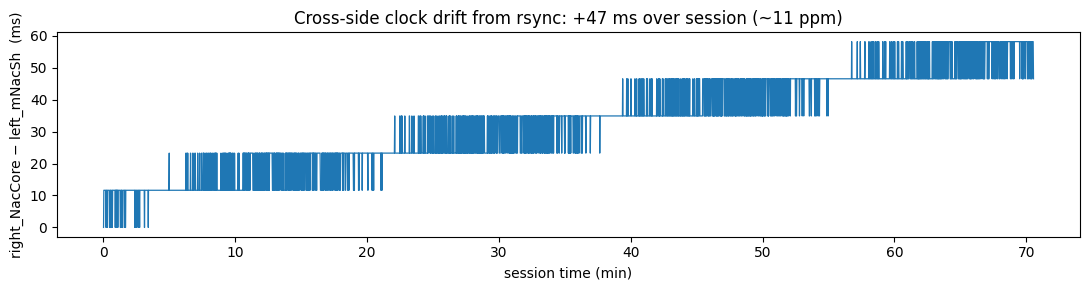

In [32]:
# Devices, stereotaxic coordinates, and cross-side clock drift (from the shared rsync).
import pandas as pd

fpt = nwb.get_lab_meta_data("fiber_photometry").fiber_photometry_table.to_dataframe()
device_view = pd.DataFrame({
    "location": fpt["location"],
    "coords(AP,ML,DV)": [list(np.round(np.asarray(c), 2)) for c in fpt["coordinates"]],
    "indicator": [i.name for i in fpt["indicator"]],
    "excitation": [s.name for s in fpt["excitation_source"]],
    "fiber": [f.name for f in fpt["optical_fiber"]],
})
print(device_view.to_string(index=False))
print("\nsurgery:", nwb.surgery)
print("\nvirus:  ", nwb.virus)

# Cross-side clock drift: match rsync pulses across the two sides. The boxes have independent
# crystals, so this should be a small slow ramp (~tens of ms) — the data needed to correct it.
a, b = SIDES[0], SIDES[1]
ta = np.asarray(nwb.acquisition[f"rsync_pulse_times_{a}"].timestamps[:])
tb = np.asarray(nwb.acquisition[f"rsync_pulse_times_{b}"].timestamps[:])
k = min(len(ta), len(tb))
drift_ms = (tb[:k] - ta[:k]) * 1000
slope_ppm = np.polyfit(ta[:k], tb[:k] - ta[:k], 1)[0] * 1e6
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(ta[:k] / 60, drift_ms, lw=0.9)
ax.set_xlabel("session time (min)"); ax.set_ylabel(f"{b} − {a}  (ms)")
ax.set_title(f"Cross-side clock drift from rsync: "
             f"{drift_ms[-1] - drift_ms[0]:+.0f} ms over session (~{slope_ppm:.0f} ppm)")
fig.tight_layout()
print(f"\nMatched {k} rsync pulses across sides; net drift {drift_ms[-1] - drift_ms[0]:+.1f} ms "
      f"(~{slope_ppm:.0f} ppm). Within a side, all streams share one clock (exact).")

In [33]:
io.close()  # uncomment when done